<a href="https://colab.research.google.com/github/mkromah/gbm-multisource-biomarker-project/blob/main/Note_Book%2004_cgga_validation_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd

PROJECT_NAME = "Glioma_ML_Biomarker_Project"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"
PROCESSED_DIR = f"{DATA_DIR}/processed"

CGGA_DIR = f"{RAW_DIR}/CGGA"
XENA_DIR = f"{RAW_DIR}/XENA"
GEO_DIR = f"{RAW_DIR}/GEO"

RESULTS_DIR = f"{BASE_DIR}/results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"
MODELS_DIR = f"{BASE_DIR}/models"

print("Shared project configuration loaded successfully.")
print("Project root:", BASE_DIR)

Shared project configuration loaded successfully.
Project root: /content/drive/MyDrive/Glioma_ML_Biomarker_Project


In [ ]:
# ============================================================
# Step 2: Load CGGA expression dataset
# ============================================================

CGGA_EXPR_FILE = f"{CGGA_DIR}/CGGA.mRNAseq_693.RSEM-genes.20200506.txt"

cgga_expr = pd.read_csv(
    CGGA_EXPR_FILE,
    sep="\t"
)

print("CGGA expression dataset loaded successfully.")
print("Dataset shape:", cgga_expr.shape)

cgga_expr.head()

CGGA expression dataset loaded successfully.
Dataset shape: (23987, 694)


,Gene_Name,CGGA_1002,CGGA_1003,CGGA_1010,CGGA_1012,CGGA_1014,CGGA_1017,CGGA_1018,CGGA_103,CGGA_1030,...,CGGA_P633,CGGA_P7,CGGA_P83,CGGA_P84,CGGA_P86,CGGA_P87,CGGA_P89,CGGA_P93,CGGA_P98,CGGA_P99
0,A1BG,68.65,14.06,5.28,101.52,93.44,18.85,27.46,10.49,34.71,...,4.14,27.32,29.36,8.57,7.97,78.61,39.75,42.07,53.78,115.19
1,A1BG-AS1,3.85,1.52,1.08,3.64,4.86,3.37,2.80,1.69,6.88,...,0.98,4.36,1.40,0.84,1.46,3.74,5.27,3.71,2.70,3.68
2,A2M,107.13,44.50,11.15,168.40,75.97,51.23,38.94,48.13,32.93,...,152.55,444.89,122.16,90.51,91.39,241.18,667.63,187.61,82.40,82.42
3,A2M-AS1,0.22,0.09,0.17,0.24,0.28,0.59,0.18,0.26,0.61,...,0.18,0.80,0.08,0.29,0.13,0.31,0.63,0.18,0.23,0.19
4,A2ML1,0.76,2.28,0.17,1.63,2.20,0.86,2.47,4.56,0.72,...,0.63,0.15,2.85,5.52,2.71,0.75,0.04,3.94,1.35,2.59


In [ ]:
# ============================================================
# Step 3: Load CGGA clinical dataset
# ============================================================

CGGA_CLINICAL_FILE = f"{CGGA_DIR}/CGGA.mRNAseq_693_clinical.20200506.txt"

cgga_clinical = pd.read_csv(
    CGGA_CLINICAL_FILE,
    sep="\t"
)

print("CGGA clinical dataset loaded successfully.")
print("Dataset shape:", cgga_clinical.shape)

cgga_clinical.head()

CGGA clinical dataset loaded successfully.
Dataset shape: (693, 13)


,CGGA_ID,PRS_type,Histology,Grade,Gender,Age,OS,Censor (alive=0; dead=1),Radio_status (treated=1;un-treated=0),Chemo_status (TMZ treated=1;un-treated=0),IDH_mutation_status,1p19q_codeletion_status,MGMTp_methylation_status
0,CGGA_1002,Primary,AA,WHO III,Female,43.0,305.0,1.0,1.0,1.0,Wildtype,Non-codel,methylated
1,CGGA_1003,Primary,O,WHO II,Female,47.0,3817.0,0.0,0.0,1.0,Mutant,Codel,un-methylated
2,CGGA_1010,Primary,A,WHO II,Male,45.0,246.0,1.0,1.0,1.0,Mutant,NaN,un-methylated
3,CGGA_1012,Recurrent,rO,WHO II,Male,45.0,3679.0,1.0,1.0,1.0,Mutant,Non-codel,un-methylated
4,CGGA_1014,Primary,A,WHO II,Male,42.0,263.0,1.0,0.0,1.0,Wildtype,Non-codel,un-methylated


In [ ]:
# ============================================================
# Step 4: Inspect histology distribution
# ============================================================

histology_counts = cgga_clinical["Histology"].value_counts()

print("Histology distribution in CGGA dataset:\n")
print(histology_counts)

Histology distribution in CGGA dataset:

Histology
GBM     140
rGBM    109
A        85
AA       82
rAA      70
AO       46
O        45
rAO      36
rA       34
AOA      16
rO       15
OA        8
rAOA      5
rOA       1
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 5: Create binary GBM vs LGG labels
# ============================================================

# Define GBM categories
gbm_types = ["GBM", "rGBM"]

# Create binary label column
cgga_clinical["tumor_label"] = cgga_clinical["Histology"].apply(
    lambda x: 1 if x in gbm_types else 0
)

print("Binary tumor labels created successfully.\n")

print("Label distribution:")
print(cgga_clinical["tumor_label"].value_counts())

Binary tumor labels created successfully.

Label distribution:
tumor_label
0    444
1    249
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 6: Extract expression sample IDs
# ============================================================

expr_sample_ids = cgga_expr.columns[1:]  # exclude Gene_Name column

print("Total expression samples:", len(expr_sample_ids))
print("\nFirst 10 sample IDs:\n")

print(list(expr_sample_ids[:10]))

Total expression samples: 693

First 10 sample IDs:

['CGGA_1002', 'CGGA_1003', 'CGGA_1010', 'CGGA_1012', 'CGGA_1014', 'CGGA_1017', 'CGGA_1018', 'CGGA_103', 'CGGA_1030', 'CGGA_1032']


In [ ]:
# ============================================================
# Step 7: Transpose expression matrix
# ============================================================

cgga_expr_t = cgga_expr.set_index("Gene_Name").T

print("Expression matrix transposed successfully.")
print("New shape:", cgga_expr_t.shape)

cgga_expr_t.head()

Expression matrix transposed successfully.
New shape: (693, 23987)


Gene_Name,A1BG,A1BG-AS1,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,AAAS,AACS,...,ZYX,ZZEF1,ZZZ3,hsa-mir-1199,hsa-mir-125a,hsa-mir-335,hsa-mir-6080,hsa-mir-6723,hsa-mir-7162,hsa-mir-8072
CGGA_1002,68.65,3.85,107.13,0.22,0.76,0.25,0.05,4.18,34.94,33.29,...,100.92,6.11,14.06,51.53,0.06,0.03,13.28,163.33,0.00,5.18
CGGA_1003,14.06,1.52,44.50,0.09,2.28,0.05,0.16,0.86,51.14,4.62,...,53.37,27.50,4.25,15.61,0.26,0.08,12.16,402.29,0.05,3.59
CGGA_1010,5.28,1.08,11.15,0.17,0.17,0.04,0.00,0.15,9.99,1.65,...,4.91,9.21,4.92,1.21,0.00,0.07,0.61,0.43,0.00,0.66
CGGA_1012,101.52,3.64,168.40,0.24,1.63,0.14,0.23,4.82,43.53,8.62,...,99.72,7.73,16.02,10.33,0.34,0.04,7.53,211.15,0.14,1.88
CGGA_1014,93.44,4.86,75.97,0.28,2.20,0.77,0.56,3.24,44.31,24.16,...,175.54,6.63,7.72,22.21,0.16,0.06,12.18,172.12,0.05,4.13


In [ ]:
# ============================================================
# Step 8: Attach tumor labels to expression matrix
# ============================================================

# Create mapping from sample ID → tumor label
label_map = cgga_clinical.set_index("CGGA_ID")["tumor_label"]

# Add labels to expression dataset
cgga_expr_t["tumor_label"] = cgga_expr_t.index.map(label_map)

print("Tumor labels added successfully.\n")

print("Label distribution:")
print(cgga_expr_t["tumor_label"].value_counts())

Tumor labels added successfully.

Label distribution:
tumor_label
0    444
1    249
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 9: Load TCGA biomarker ranking
# ============================================================

BIOMARKER_FILE = f"{RESULTS_DIR}/xena_gene_importance_ranking.csv"

biomarker_df = pd.read_csv(BIOMARKER_FILE)

print("Biomarker ranking loaded successfully.")
print("Total genes:", biomarker_df.shape[0])

biomarker_df.head()

Biomarker ranking loaded successfully.
Total genes: 5000


,gene,importance
0,ENSG00000223551.1,0.030984
1,ENSG00000234743.1,0.023894
2,ENSG00000236058.3,0.023892
3,ENSG00000217094.2,0.022190
4,ENSG00000185834.10,0.019463


In [ ]:
# ============================================================
# Step 10: Extract biomarker gene symbols
# ============================================================

# Load annotated biomarker file if saved previously
ANNOTATED_FILE = f"{RESULTS_DIR}/xena_gene_importance_ranking.csv"

biomarker_df = pd.read_csv(ANNOTATED_FILE)

# Remove version numbers from Ensembl IDs
biomarker_df["ensembl_id"] = biomarker_df["gene"].str.split(".").str[0]

print("First rows of biomarker table:")
display(biomarker_df.head())

First rows of biomarker table:


,gene,importance,ensembl_id
0,ENSG00000223551.1,0.030984,ENSG00000223551
1,ENSG00000234743.1,0.023894,ENSG00000234743
2,ENSG00000236058.3,0.023892,ENSG00000236058
3,ENSG00000217094.2,0.022190,ENSG00000217094
4,ENSG00000185834.10,0.019463,ENSG00000185834


In [ ]:
# ============================================================
# Step 11: Convert biomarker Ensembl IDs to gene symbols
# ============================================================

PROBEMAP_FILE = f"{XENA_DIR}/probeMap_gencode.v23.annotation.gene.probemap"

gene_map = pd.read_csv(PROBEMAP_FILE, sep="\t")

# Remove version numbers
gene_map["ensembl_id"] = gene_map["id"].str.split(".").str[0]

# Merge biomarker list with gene annotation
biomarker_annotated = biomarker_df.merge(
    gene_map[["ensembl_id", "gene"]],
    on="ensembl_id",
    how="left"
)

biomarker_annotated = biomarker_annotated.rename(
    columns={"gene_x": "ensembl_gene", "gene_y": "gene_symbol"}
)

print("Biomarker annotation completed.")
print("Total annotated genes:", biomarker_annotated.shape[0])

biomarker_annotated.head()

Biomarker annotation completed.
Total annotated genes: 5000


,ensembl_gene,importance,ensembl_id,gene_symbol
0,ENSG00000223551.1,0.030984,ENSG00000223551,TMSB4XP4
1,ENSG00000234743.1,0.023894,ENSG00000234743,EIF5AP4
2,ENSG00000236058.3,0.023892,ENSG00000236058,RP11-215A21.2
3,ENSG00000217094.2,0.022190,ENSG00000217094,PPIAP31
4,ENSG00000185834.10,0.019463,ENSG00000185834,RPL12P4


In [ ]:
# ============================================================
# Step 12: Find shared genes between TCGA and CGGA
# ============================================================

# TCGA biomarker gene symbols
tcga_genes = set(biomarker_annotated["gene_symbol"].dropna())

# CGGA genes
cgga_genes = set(cgga_expr_t.columns)

# Intersection
shared_genes = list(tcga_genes.intersection(cgga_genes))

print("Total TCGA biomarker genes:", len(tcga_genes))
print("Total CGGA genes:", len(cgga_genes))
print("Shared genes:", len(shared_genes))

Total TCGA biomarker genes: 4990
Total CGGA genes: 23988
Shared genes: 4394


In [ ]:
# ============================================================
# Step 13: Filter CGGA dataset to shared biomarker genes
# ============================================================

cgga_features = cgga_expr_t[shared_genes]

print("CGGA feature matrix created.")
print("Shape:", cgga_features.shape)

cgga_features.head()

CGGA feature matrix created.
Shape: (693, 4394)


Gene_Name,ELAVL4,GSX1,CA12,RP4-610C12.3,CENPA,RS1,AJAP1,GDF7,RP4-555D20.2,DUSP9,...,AC026150.6,RP11-433J8.1,RP1-161N10.1,ADIG,SEZ6,PENK,RP11-285F16.1,RP11-307B6.3,CH25H,NPIPB15
CGGA_1002,13.44,4.61,1.44,1.35,2.22,0.33,2.72,0.00,4.91,1.97,...,0.20,2.38,0.00,0.00,24.70,6.42,10.32,4.87,12.71,17.46
CGGA_1003,27.85,15.53,2.78,0.32,0.67,0.15,0.78,0.14,2.42,1.97,...,0.16,0.31,0.17,0.50,59.04,0.68,4.14,6.52,3.78,17.37
CGGA_1010,5.03,0.26,0.11,0.96,0.56,0.00,1.68,0.09,0.01,0.18,...,0.00,0.00,0.15,0.00,15.01,0.00,0.00,0.21,0.00,0.14
CGGA_1012,4.82,0.17,10.76,1.01,2.76,0.00,1.11,0.27,1.03,0.25,...,0.00,0.09,0.00,0.11,4.54,1.51,1.57,0.56,5.56,11.26
CGGA_1014,7.85,10.33,3.14,0.22,3.99,0.11,1.85,0.01,5.90,2.05,...,0.19,1.12,0.00,1.04,149.39,6.16,6.83,3.08,16.03,22.52


In [ ]:
# ============================================================
# Step 14: Attach tumor labels correctly
# ============================================================

# Create sample ID -> label mapping from the clinical table
cgga_label_map = cgga_clinical.set_index("CGGA_ID")["tumor_label"]

# Add labels to the CGGA feature matrix using its index
cgga_features = cgga_features.copy()
cgga_features.loc[:, "tumor_label"] = cgga_features.index.map(cgga_label_map)

print("Tumor labels added to CGGA feature matrix.")

print("\nDataset shape:")
print(cgga_features.shape)

print("\nLabel distribution:")
print(cgga_features["tumor_label"].value_counts())

Tumor labels added to CGGA feature matrix.

Dataset shape:
(693, 4395)

Label distribution:
tumor_label
0    444
1    249
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 15: Separate features and labels
# ============================================================

X_cgga = cgga_features.drop(columns=["tumor_label"])
y_cgga = cgga_features["tumor_label"]

print("CGGA ML dataset prepared.")

print("\nFeature matrix shape:", X_cgga.shape)
print("Label vector shape:", y_cgga.shape)

print("\nLabel distribution:")
print(y_cgga.value_counts())

CGGA ML dataset prepared.

Feature matrix shape: (693, 4394)
Label vector shape: (693,)

Label distribution:
tumor_label
0    444
1    249
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# ============================================================
# Step 16: Train-test split for CGGA validation
# ============================================================

X_train_cgga, X_test_cgga, y_train_cgga, y_test_cgga = train_test_split(
    X_cgga,
    y_cgga,
    test_size=0.2,
    stratify=y_cgga,
    random_state=42
)

print("CGGA train-test split completed.\n")

print("Training shape:", X_train_cgga.shape)
print("Test shape:", X_test_cgga.shape)

print("\nTraining label distribution:")
print(y_train_cgga.value_counts())

print("\nTest label distribution:")
print(y_test_cgga.value_counts())

CGGA train-test split completed.

Training shape: (554, 4394)
Test shape: (139, 4394)

Training label distribution:
tumor_label
0    355
1    199
Name: count, dtype: int64

Test label distribution:
tumor_label
0    89
1    50
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# Step 17: Train CGGA validation model
# ============================================================

rf_cgga = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_cgga.fit(X_train_cgga, y_train_cgga)

print("Random Forest validation model trained successfully.")

Random Forest validation model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ============================================================
# Step 18: Evaluate model on CGGA test dataset
# ============================================================

y_pred = rf_cgga.predict(X_test_cgga)
y_prob = rf_cgga.predict_proba(X_test_cgga)[:, 1]

accuracy = accuracy_score(y_test_cgga, y_pred)
roc_auc = roc_auc_score(y_test_cgga, y_prob)

print("CGGA Validation Performance")
print("----------------------------------------")
print("Accuracy:", round(accuracy, 4))
print("ROC-AUC :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test_cgga, y_pred))

CGGA Validation Performance
----------------------------------------
Accuracy: 0.7914
ROC-AUC : 0.8879

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84        89
           1       0.73      0.66      0.69        50

    accuracy                           0.79       139
   macro avg       0.78      0.76      0.77       139
weighted avg       0.79      0.79      0.79       139



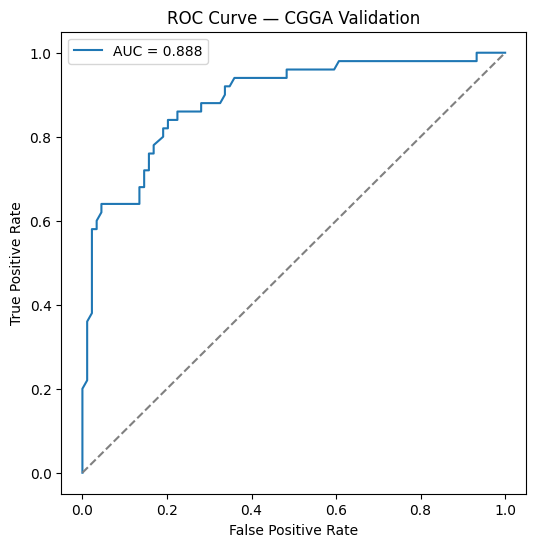

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ============================================================
# Step 19: ROC curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test_cgga, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — CGGA Validation")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# Step 20: Compute CGGA feature importance
# ============================================================

import pandas as pd

importance_scores = rf_cgga.feature_importances_

importance_df = pd.DataFrame({
    "gene": X_train_cgga.columns,
    "importance": importance_scores
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("Top 20 most important genes in CGGA validation:\n")
importance_df.head(20)

Top 20 most important genes in CGGA validation:



,gene,importance
954,CHI3L1,0.006610
3149,IGFBP2,0.005512
3996,METTL7B,0.005395
57,MMP9,0.005371
3546,SYT15,0.005314
3429,EVC2,0.005236
2867,CD58,0.004736
3383,G0S2,0.004607
1021,PDLIM4,0.004539
4005,ADM,0.004518


In [ ]:
# ============================================================
# Step 21: Identify overlapping top biomarkers
# ============================================================

# Top biomarkers from TCGA discovery cohort
tcga_top100 = set(biomarker_annotated["gene_symbol"].dropna().head(100))

# Top biomarkers from CGGA validation cohort
cgga_top100 = set(importance_df["gene"].dropna().head(100))

# Overlap
shared_top_biomarkers = sorted(tcga_top100.intersection(cgga_top100))

print("Top 100 TCGA biomarkers:", len(tcga_top100))
print("Top 100 CGGA biomarkers:", len(cgga_top100))
print("Shared biomarkers:", len(shared_top_biomarkers))

print("\nShared top biomarkers:")
print(shared_top_biomarkers)

Top 100 TCGA biomarkers: 100
Top 100 CGGA biomarkers: 100
Shared biomarkers: 21

Shared top biomarkers:
['AGAP2-AS1', 'ANXA2', 'CA9', 'CCDC109B', 'CLIC1', 'EMP3', 'ESM1', 'FN1', 'GDF15', 'KCNB1', 'LINC00152', 'LOX', 'MMP9', 'PLEK2', 'RAB34', 'SERPINH1', 'SH2D4A', 'SPAG4', 'TAGLN2', 'TNFRSF12A', 'TUBA1C']


In [ ]:
# ============================================================
# Step 22: Final biomarker table
# ============================================================

final_biomarkers = importance_df[
    importance_df["gene"].isin(shared_top_biomarkers)
].sort_values(by="importance", ascending=False)

print("Final cross-cohort biomarker panel:")
final_biomarkers

Final cross-cohort biomarker panel:


,gene,importance
57,MMP9,0.005371
1038,LINC00152,0.004322
830,ESM1,0.004122
1379,CLIC1,0.004014
697,SERPINH1,0.003402
3570,AGAP2-AS1,0.003313
2226,KCNB1,0.003149
3370,ANXA2,0.003001
1901,LOX,0.002576
1576,CCDC109B,0.002571


In [ ]:
# ============================================================
# Step 23: Save final biomarker panel
# ============================================================

final_biomarker_path = f"{RESULTS_DIR}/final_cross_cohort_biomarkers.csv"

final_biomarkers.to_csv(final_biomarker_path, index=False)

print("Final cross-cohort biomarker panel saved successfully.")
print("Location:", final_biomarker_path)

Final cross-cohort biomarker panel saved successfully.
Location: /content/drive/MyDrive/Glioma_ML_Biomarker_Project/results/final_cross_cohort_biomarkers.csv
